In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import re
from collections import Counter

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/SeventhSemMl/transaction_dataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (4501043, 4)

First few rows:


,transaction_description,category,country,currency
0,Wage,Income,USA,USD
1,Arby's (Contactless),Food & Dining,AUSTRALIA,AUD
2,Occupational Therapy,Healthcare & Medical,USA,USD
3,Potbelly Store Branch,Food & Dining,UK,GBP
4,Amazon - AUSTRALIA,Shopping & Retail,AUSTRALIA,AUD


In [3]:
# Check data types and missing values
print("Dataset Info:")
print(df.info())

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Basic Statistics:")
print(df.describe())

# Focus on columns we need
print("\n" + "="*50)
print("Columns we're using for categorization:")
print(df[['transaction_description', 'category']].head(10))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4501043 entries, 0 to 4501042
Data columns (total 4 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   transaction_description  object
 1   category                 object
 2   country                  object
 3   currency                 object
dtypes: object(4)
memory usage: 137.4+ MB
None

Missing Values:
transaction_description    0
category                   0
country                    0
currency                   0
dtype: int64

Basic Statistics:
       transaction_description              category    country currency
count                  4501043               4501043    4501043  4501043
unique                 1387044                    10          5        5
top                    Payroll  Utilities & Services  AUSTRALIA      AUD
freq                      5660                451842     901765   901765

Columns we're using for categorization:
                    transaction_de

Number of unique categories: 10


Category Distribution:
category
Utilities & Services          451842
Government & Legal            451108
Financial Services            450959
Income                        450545
Charity & Donations           450133
Shopping & Retail             449941
Healthcare & Medical          449857
Entertainment & Recreation    449495
Transportation                449235
Food & Dining                 447928
Name: count, dtype: int64


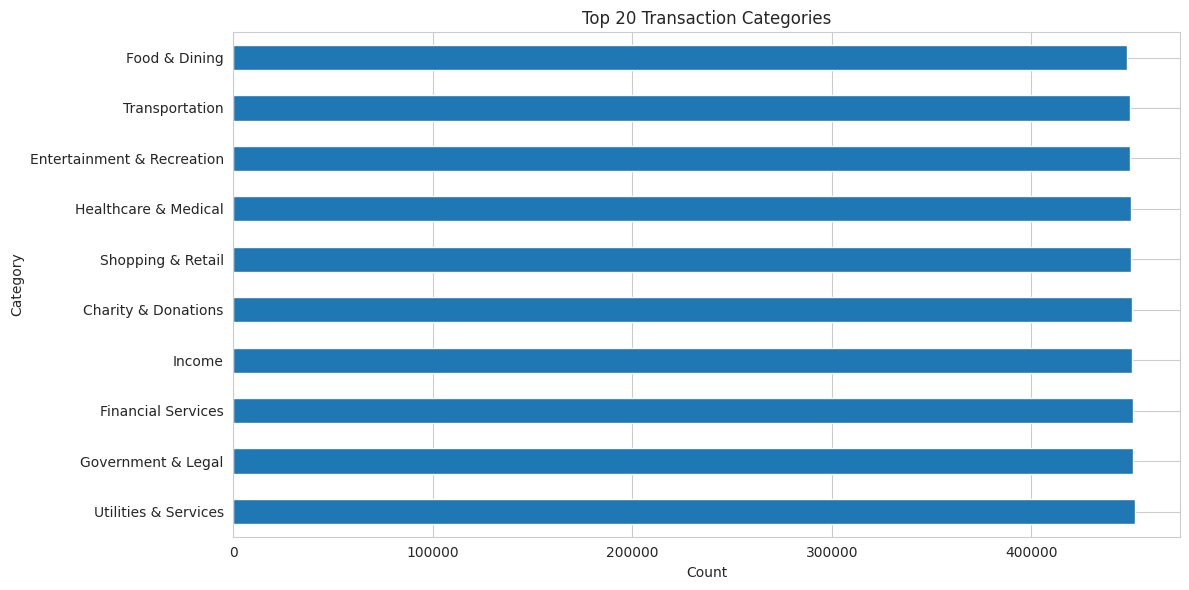


Class Imbalance Check:
Most common category: Utilities & Services (451842 transactions)
Least common category: Food & Dining (447928 transactions)
Imbalance ratio: 1.01x


In [4]:
# Analyze category distribution
print("Number of unique categories:", df['category'].nunique())
print("\n" + "="*50)

# Category counts
category_counts = df['category'].value_counts()
print("\nCategory Distribution:")
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(12, 6))
category_counts.head(20).plot(kind='barh')
plt.title('Top 20 Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Check for class imbalance
print("\n" + "="*50)
print("Class Imbalance Check:")
print(f"Most common category: {category_counts.index[0]} ({category_counts.iloc[0]} transactions)")
print(f"Least common category: {category_counts.index[-1]} ({category_counts.iloc[-1]} transactions)")
print(f"Imbalance ratio: {category_counts.iloc[0] / category_counts.iloc[-1]:.2f}x")

In [5]:
# Analyze transaction descriptions
print("Sample transaction descriptions per category:\n")

# Show examples from each category
for category in df['category'].unique()[:10]:  # First 10 categories
    print(f"\n{category.upper()}:")
    samples = df[df['category'] == category]['transaction_description'].head(3).values
    for i, sample in enumerate(samples, 1):
        print(f"  {i}. {sample}")
    print("-" * 50)

Sample transaction descriptions per category:


INCOME:
  1. Wage
  2. Dividend - AUSTRALIA
  3. Direct Deposit - CANADA
--------------------------------------------------

FOOD & DINING:
  1. Arby's (Contactless)
  2. Potbelly Store Branch
  3. Dairy Queen
--------------------------------------------------

HEALTHCARE & MEDICAL:
  1. Occupational Therapy
  2. UCLA Medical #7731 - UK Center TXN176162
  3. Walgreens #8780
--------------------------------------------------

SHOPPING & RETAIL:
  1. Amazon - AUSTRALIA
  2. Walmart Store
  3. TJ Maxx
--------------------------------------------------

UTILITIES & SERVICES:
  1. Starlink
  2. Cox
  3. Public WiFi #7514
--------------------------------------------------

ENTERTAINMENT & RECREATION:
  1. Tennis Court #7639 - AUSTRALIA
  2. Equinox #2852
  3. Planet Fitness TXN722088
--------------------------------------------------

FINANCIAL SERVICES:
  1. Retirement TXN109720
  2. PNC Bank - INDIA
  3. PNC Bank
-----------------------------

Description Statistics:
        desc_length    word_count
count  4.501043e+06  4.501043e+06
mean   1.904819e+01  3.078469e+00
std    8.911098e+00  1.486948e+00
min    2.000000e+00  1.000000e+00
25%    1.200000e+01  2.000000e+00
50%    1.800000e+01  3.000000e+00
75%    2.500000e+01  4.000000e+00
max    7.100000e+01  1.200000e+01


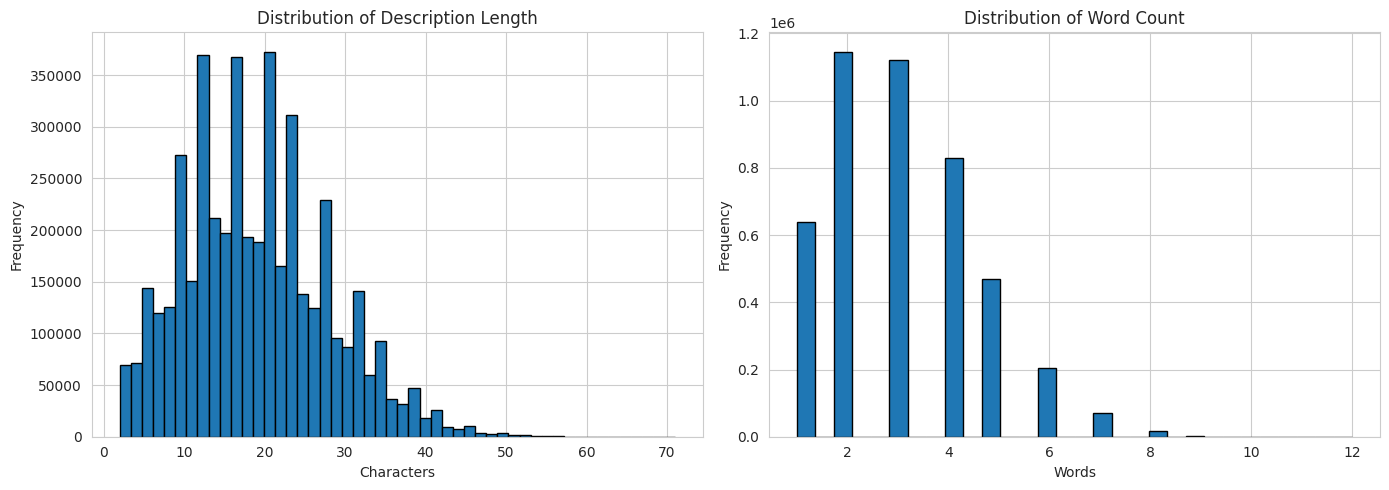


Potential data quality issues:
Very short descriptions (<5 chars): 140579
Very long descriptions (>100 chars): 0
Empty descriptions: 0


In [6]:
# Analyze description lengths
df['desc_length'] = df['transaction_description'].str.len()
df['word_count'] = df['transaction_description'].str.split().str.len()

print("Description Statistics:")
print(df[['desc_length', 'word_count']].describe())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Description length distribution
axes[0].hist(df['desc_length'], bins=50, edgecolor='black')
axes[0].set_title('Distribution of Description Length')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# Word count distribution
axes[1].hist(df['word_count'], bins=30, edgecolor='black')
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check for very short or very long descriptions
print("\n" + "="*50)
print("Potential data quality issues:")
print(f"Very short descriptions (<5 chars): {(df['desc_length'] < 5).sum()}")
print(f"Very long descriptions (>100 chars): {(df['desc_length'] > 100).sum()}")
print(f"Empty descriptions: {df['transaction_description'].isna().sum()}")

In [7]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 2940825


In [8]:
print("Data Preparation")
print("="*70)

# Step 1: Drop country and currency columns
print("\nStep 1: Drop unnecessary columns")
print(f"  Original columns: {list(df.columns)}")

df_model = df[['transaction_description', 'category']].copy()

print(f"  Kept columns: {list(df_model.columns)}")
print(f"  Total rows: {len(df_model):,}")

Data Preparation

Step 1: Drop unnecessary columns
  Original columns: ['transaction_description', 'category', 'country', 'currency', 'desc_length', 'word_count']
  Kept columns: ['transaction_description', 'category']
  Total rows: 4,501,043


In [9]:
# Step 2: Remove exact duplicates
print("\nStep 2: Remove duplicate rows")
print(f"  Before: {len(df_model):,} rows")

df_model = df_model.drop_duplicates()

print(f"  After: {len(df_model):,} rows")
print(f"  Removed: {len(df) - len(df_model):,} duplicates")


Step 2: Remove duplicate rows
  Before: 4,501,043 rows
  After: 1,389,529 rows
  Removed: 3,111,514 duplicates


In [10]:
# Step 3: Check final dataset
print("\nStep 3: Final Dataset Summary")
print(f"  Total rows: {len(df_model):,}")
print(f"  Unique descriptions: {df_model['transaction_description'].nunique():,}")
print(f"  Categories: {df_model['category'].nunique()}")

print("\n  Category distribution:")
print(df_model['category'].value_counts())

print("\n  Sample data:")
print(df_model.head(10))

print("\n Data preparation complete!")


Step 3: Final Dataset Summary
  Total rows: 1,389,529
  Unique descriptions: 1,387,044
  Categories: 10

  Category distribution:
category
Shopping & Retail             140250
Transportation                140162
Food & Dining                 140096
Entertainment & Recreation    139823
Financial Services            139262
Government & Legal            139211
Healthcare & Medical          138841
Utilities & Services          138143
Charity & Donations           137375
Income                        136366
Name: count, dtype: int64

  Sample data:
                    transaction_description              category
0                                      Wage                Income
1                      Arby's (Contactless)         Food & Dining
2                      Occupational Therapy  Healthcare & Medical
3                     Potbelly Store Branch         Food & Dining
4                        Amazon - AUSTRALIA     Shopping & Retail
5                               Dairy Queen         

In [11]:
import re

def clean_transaction_description(text):
    """
    Clean transaction description for ML model
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove country names (they appear as suffixes)
    text = re.sub(r'\s*-\s*(australia|canada|india|uk|usa)\s*', ' ', text)

    # Remove transaction IDs and reference numbers
    text = re.sub(r'txn\d+', '', text)  # TXN123456
    text = re.sub(r'#\d+', '', text)     # #1234

    # Remove common noise words
    text = re.sub(r'\(contactless\)', '', text)
    text = re.sub(r'\bonline\b', '', text)
    text = re.sub(r'\bstore\b', '', text)
    text = re.sub(r'\bbranch\b', '', text)
    text = re.sub(r'\bstation\b', '', text)

    # Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    # Strip leading/trailing whitespace
    text = text.strip()

    return text

In [12]:
print("Applying cleaning to entire dataset...")
print("="*70)

# Apply cleaning function
df_model['cleaned_description'] = df_model['transaction_description'].apply(clean_transaction_description)

# Check for empty descriptions after cleaning
empty_count = (df_model['cleaned_description'].str.len() == 0).sum()
print(f"\nDescriptions that became empty after cleaning: {empty_count}")

if empty_count > 0:
    print("\nExamples of empty descriptions:")
    print(df_model[df_model['cleaned_description'].str.len() == 0][['transaction_description', 'category']].head(10))

    # Remove empty descriptions
    df_model = df_model[df_model['cleaned_description'].str.len() > 0].copy()
    print(f"\nRemoved {empty_count} empty descriptions")

print(f"\nFinal dataset size: {len(df_model):,} rows")

# Check cleaned data statistics
df_model['cleaned_length'] = df_model['cleaned_description'].str.len()
df_model['cleaned_word_count'] = df_model['cleaned_description'].str.split().str.len()

print("\nCleaned Description Statistics:")
print(df_model[['cleaned_length', 'cleaned_word_count']].describe())

# Show examples
print("\n" + "="*70)
print("Before/After Examples:\n")
sample = df_model.sample(15)
for idx, row in sample.iterrows():
    print(f"Category: {row['category']}")
    print(f"  Original: {row['transaction_description']}")
    print(f"  Cleaned:  {row['cleaned_description']}")
    print()

Applying cleaning to entire dataset...

Descriptions that became empty after cleaning: 1

Examples of empty descriptions:
        transaction_description           category
4501040                  500.00  Shopping & Retail

Removed 1 empty descriptions

Final dataset size: 1,389,528 rows

Cleaned Description Statistics:
       cleaned_length  cleaned_word_count
count    1.389528e+06        1.389528e+06
mean     1.351584e+01        2.104400e+00
std      6.855550e+00        9.689206e-01
min      2.000000e+00        1.000000e+00
25%      8.000000e+00        1.000000e+00
50%      1.300000e+01        2.000000e+00
75%      1.800000e+01        3.000000e+00
max      5.200000e+01        7.000000e+00

Before/After Examples:

Category: Income
  Original: Credit Online Center - Lunch Time
  Cleaned:  credit center lunch time

Category: Financial Services
  Original: Tax Preparation #8018 - Lunch Time
  Cleaned:  tax preparation lunch time

Category: Healthcare & Medical
  Original: Urologist #119

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Preparing Data for Model Training")
print("="*70)

# Use cleaned descriptions and categories
X = df_model['cleaned_description']
y = df_model['category']

print(f"Total samples: {len(X):,}")
print(f"Number of categories: {y.nunique()}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Keep category distribution balanced in train/test
)

print(f"\nTrain set: {len(X_train):,} samples")
print(f"Test set:  {len(X_test):,} samples")

print("\nCategory distribution in training set:")
print(y_train.value_counts())

print("\nCategory distribution in test set:")
print(y_test.value_counts())

Preparing Data for Model Training
Total samples: 1,389,528
Number of categories: 10

Train set: 1,111,622 samples
Test set:  277,906 samples

Category distribution in training set:
category
Shopping & Retail             112199
Transportation                112129
Food & Dining                 112077
Entertainment & Recreation    111858
Financial Services            111410
Government & Legal            111369
Healthcare & Medical          111073
Utilities & Services          110514
Charity & Donations           109900
Income                        109093
Name: count, dtype: int64

Category distribution in test set:
category
Shopping & Retail             28050
Transportation                28033
Food & Dining                 28019
Entertainment & Recreation    27965
Financial Services            27852
Government & Legal            27842
Healthcare & Medical          27768
Utilities & Services          27629
Charity & Donations           27475
Income                        27273
Name: cou

In [14]:
print("\nCreating TF-IDF Features")
print("="*70)

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=1000,      # Use top 1000 most important words
    ngram_range=(1, 2),     # Use single words and 2-word phrases
    min_df=2,               # Word must appear at least 2 times
    max_df=0.8              # Ignore words appearing in >80% of documents
)

# Fit on training data and transform
print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)
print(f"Training features shape: {X_train_tfidf.shape}")

# Transform test data (don't fit again!)
X_test_tfidf = tfidf.transform(X_test)
print(f"Test features shape: {X_test_tfidf.shape}")

print(f"\nVocabulary size: {len(tfidf.vocabulary_):,} unique terms")

# Show most important features
print("\nTop 20 most important words/phrases:")
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])


Creating TF-IDF Features
Fitting TF-IDF on training data...
Training features shape: (1111622, 1000)
Test features shape: (277906, 1000)

Vocabulary size: 1,000 unique terms

Top 20 most important words/phrases:
['accounting' 'ach' 'adidas' 'advisor' 'afternoon' 'aid' 'aid center'
 'airlines' 'airlines center' 'airport' 'alamo' 'alaska' 'alaska airlines'
 'allegiant' 'alley' 'amazon' 'amazon prime' 'ambulance'
 'ambulance center' 'amc']


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import time

print("Training Model 1: Logistic Regression")
print("="*70)

# Initialize model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train
print("Training...")
start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds")

# Predict
print("Making predictions on test set...")
start_time = time.time()
y_pred_lr = lr_model.predict(X_test_tfidf)
predict_time = time.time() - start_time
print(f"✓ Prediction completed in {predict_time:.2f} seconds")

# Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n{'='*70}")
print(f"LOGISTIC REGRESSION RESULTS")
print(f"{'='*70}")
print(f"Accuracy: {accuracy_lr*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Training Model 1: Logistic Regression
Training...
✓ Training completed in 27.55 seconds
Making predictions on test set...
✓ Prediction completed in 0.06 seconds

LOGISTIC REGRESSION RESULTS
Accuracy: 98.53%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      1.00      1.00     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       0.99      0.99      0.99     28019
        Government & Legal       0.98      0.98      0.98     27842
      Healthcare & Medical       0.98      0.96      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.95      0.95      0.95     28050
            Transportation       1.00      0.98      0.99     28033
      Utilities & Services       0.98      1.00      0.99     27629

                  a

In [16]:
from sklearn.naive_bayes import MultinomialNB

print("\nTraining Model 2: Naive Bayes")
print("="*70)

# Initialize model
nb_model = MultinomialNB()

# Train
print("Training...")
start_time = time.time()
nb_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds")

# Predict
print("Making predictions on test set...")
start_time = time.time()
y_pred_nb = nb_model.predict(X_test_tfidf)
predict_time = time.time() - start_time
print(f"✓ Prediction completed in {predict_time:.2f} seconds")

# Evaluate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\n{'='*70}")
print(f"NAIVE BAYES RESULTS")
print(f"{'='*70}")
print(f"Accuracy: {accuracy_nb*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


Training Model 2: Naive Bayes
Training...
✓ Training completed in 5.51 seconds
Making predictions on test set...
✓ Prediction completed in 0.03 seconds

NAIVE BAYES RESULTS
Accuracy: 98.23%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      1.00      1.00     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       1.00      0.98      0.99     28019
        Government & Legal       1.00      0.96      0.98     27842
      Healthcare & Medical       0.99      0.95      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.90      0.98      0.94     28050
            Transportation       0.98      0.97      0.98     28033
      Utilities & Services       0.99      0.99      0.99     27629

                  accuracy         

In [17]:
from sklearn.ensemble import RandomForestClassifier

print("\nTraining Model 3: Random Forest")
print("="*70)

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train
print("Training... (This may take a few minutes)")
start_time = time.time()
rf_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds")

# Predict
print("Making predictions on test set...")
start_time = time.time()
y_pred_rf = rf_model.predict(X_test_tfidf)
predict_time = time.time() - start_time
print(f"✓ Prediction completed in {predict_time:.2f} seconds")

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n{'='*70}")
print(f"RANDOM FOREST RESULTS")
print(f"{'='*70}")
print(f"Accuracy: {accuracy_rf*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Training Model 3: Random Forest
Training... (This may take a few minutes)
✓ Training completed in 445.60 seconds
Making predictions on test set...
✓ Prediction completed in 12.11 seconds

RANDOM FOREST RESULTS
Accuracy: 98.52%

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      1.00      1.00     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       1.00      0.98      0.99     28019
        Government & Legal       0.98      0.98      0.98     27842
      Healthcare & Medical       0.95      0.99      0.97     27768
                    Income       0.98      1.00      0.99     27273
         Shopping & Retail       0.97      0.93      0.95     28050
            Transportation       1.00      0.98      0.99     28033
      Utilities & Services       0.98      1.00      0.99     27629

In [19]:
# Install XGBoost first
!pip install xgboost -q

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print("\nTraining Model 4: XGBoost")
print("="*70)

# XGBoost requires numeric labels, so we need to encode categories
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Category encoding:")
for i, category in enumerate(label_encoder.classes_):
    print(f"  {i}: {category}")

# XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,       # Number of trees
    max_depth=6,            # Tree depth
    learning_rate=0.1,      # Learning rate
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    tree_method='hist',     # Faster training
    verbosity=1             # Show progress
)

# Train
print("\nTraining... (Should be faster than Random Forest)")
start_time = time.time()
xgb_model.fit(X_train_tfidf, y_train_encoded)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} minutes)")

# Predict
print("Making predictions on test set...")
start_time = time.time()
y_pred_xgb_encoded = xgb_model.predict(X_test_tfidf)
predict_time = time.time() - start_time
print(f"✓ Prediction completed in {predict_time:.2f} seconds")

# Convert predictions back to category names
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n{'='*70}")
print(f"XGBOOST RESULTS")
print(f"{'='*70}")
print(f"Accuracy: {accuracy_xgb*100:.2f}%")
print(f"Training time: {train_time:.2f}s ({train_time/60:.1f} min)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Training Model 4: XGBoost
Category encoding:
  0: Charity & Donations
  1: Entertainment & Recreation
  2: Financial Services
  3: Food & Dining
  4: Government & Legal
  5: Healthcare & Medical
  6: Income
  7: Shopping & Retail
  8: Transportation
  9: Utilities & Services

Training... (Should be faster than Random Forest)
✓ Training completed in 130.77 seconds (2.2 minutes)
Making predictions on test set...
✓ Prediction completed in 4.74 seconds

XGBOOST RESULTS
Accuracy: 98.30%
Training time: 130.77s (2.2 min)

Classification Report:
                            precision    recall  f1-score   support

       Charity & Donations       1.00      1.00      1.00     27475
Entertainment & Recreation       1.00      1.00      1.00     27965
        Financial Services       1.00      1.00      1.00     27852
             Food & Dining       0.98      0.98      0.98     28019
        Government & Legal       1.00      0.96      0.98     27842
      Healthcare & Medical       0.96      0.9